# Linear Interpolation

In [1]:
function linear_interpolation(x::Real, X::Vector, u::Function)
    if x ≤ minimum(X)
        return u(minimum(X))
    elseif x ≥ maximum(X)
        return u(maximum(X))
    else
        i = 1
        while x>X[i]
            i+=1
        end
        h = X[i] - X[i-1]
        return (X[i] - x)/h*u(X[i-1]) + (x - X[i-1])/h*u(X[i])
    end
end

linear_interpolation (generic function with 1 method)

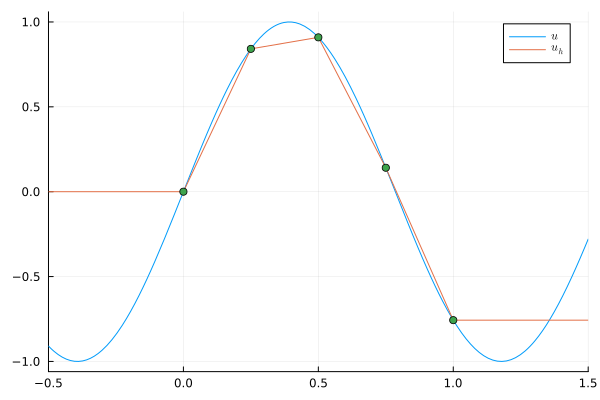

In [2]:

u(x) = sin(4*x)
N = 5
xs = collect(LinRange(0,1,N))
uh(x) = linear_interpolation(x, xs, u)

using Plots, LaTeXStrings

plot(u, xlims=(-0.5,1.5), label=L"u")
plot!(uh,label=L"u_h")
scatter!(xs,u.(xs), label="")


# Convergence

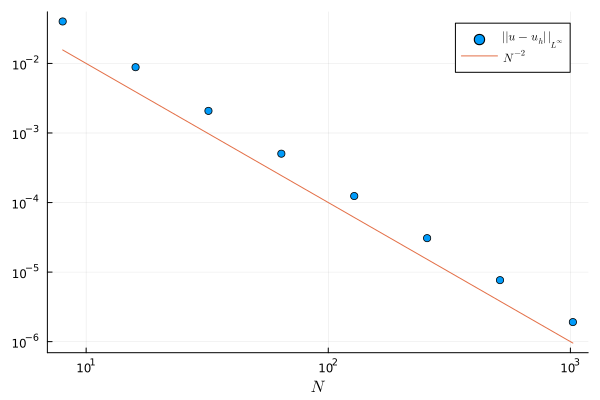

In [3]:
u(x) = sin(4*x)

Ns = 2 .^[3:1:10;]
errors = zeros(length(Ns))

x_error = 0.:1e-5:1.

for (i,N) in enumerate(Ns)
    xs = collect(LinRange(0.,1.,N))
    uh(x) = linear_interpolation(x, xs, u)

    errors[i] = maximum(abs.(u.(x_error) - uh.(x_error)))
end

plot(xscale=:log10, yscale=:log10, xlabel=L"N")
scatter!(Ns,errors, label=L"\|\|u - u_h\|\|_{L^\infty}")
plot!(x -> x^-2, label=L"N^{-2}")

In [4]:
using CurveFit
a,b = linear_fit(log.(Ns),log.(errors))
# plot!(x -> exp(a + b*log(x)), label=latexstring("$(round(a,digits=4))N^{$(round(b,digits=2))}"))

(0.9490989244333641, -2.0430721765343858)

# Convergence of the derivative

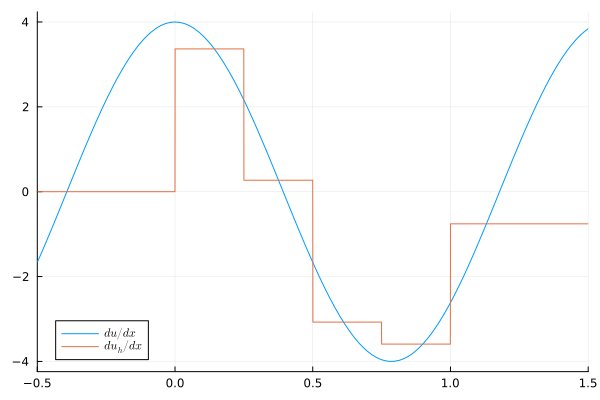

In [5]:
function linear_interpolation_derivative(x::Real, X::Vector, u::Function)
    if x ≤ minimum(X)
        return u(minimum(X))
    elseif x ≥ maximum(X)
        return u(maximum(X))
    else
        i = 1
        while x>X[i]
            i+=1
        end
        h = X[i] - X[i-1]
        return (u(X[i]) - u(X[i-1]))/h
    end
end

u(x) = sin(4*x)
dudx(x) = 4*cos(4*x)

N = 5
xs = collect(LinRange(0.,1.,N))
ys = u.(xs)
duhdx(x) = linear_interpolation_derivative(x, xs, u)

plot(dudx, xlims=(-0.5,1.5),label=L"du/dx")
plot!(duhdx, label=L"du_h/dx")


┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase /Users/david/.julia/packages/SciMLBase/DbVzk/src/performance_warnings.jl:33


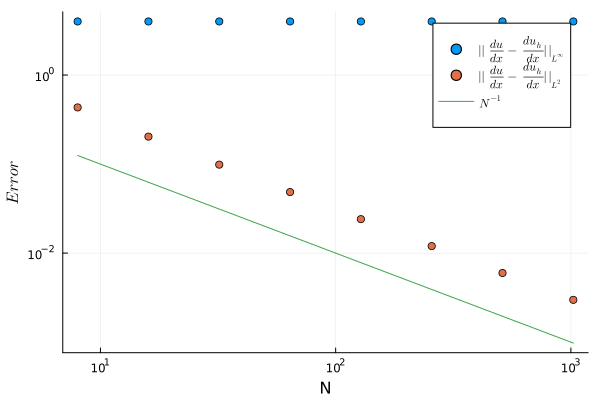

In [6]:
Ns = 2 .^[3:1:10;]
Linftyerrors_derivative = zeros(length(Ns))
L2errors_derivative = zeros(length(Ns))

x_error = 0.:1e-5:1.
dx_error = x_error[2]-x_error[1]

using Integrals 

for (i,N) in enumerate(Ns)
    xs = collect(LinRange(0.,1.,N))
    duhdx(x) = linear_interpolation_derivative(x, xs, u)

    Linftyerrors_derivative[i] = maximum(abs.(dudx.(x_error) - duhdx.(x_error)))

    errorf(x, p) = (dudx(x) - duhdx(x))^2
    p = []
    domain = (0, 1) # (lb, ub)
    prob = IntegralProblem(errorf, domain, p)
    sol = solve(prob, QuadGKJL())
    L2errors_derivative[i] = sqrt(sol.u)
end

plot(xscale=:log10, yscale=:log10, xlabel="N", ylabel=L"Error")
scatter!(Ns,Linftyerrors_derivative, label=L"\|\|\frac{du}{dx} - \frac{du_h}{dx}\|\|_{L^\infty}")
scatter!(Ns,L2errors_derivative, label=L"\|\|\frac{du}{dx} - \frac{du_h}{dx}\|\|_{L^2}")
plot!(x->x^(-1), label=L"N^{-1}")

In [7]:
a,b = linear_fit(log.(Ns),log.(L2errors_derivative))

(1.2465646369881667, -1.0217418003731669)